**TASK 2 : MOVIE RATING PREDICTION WITH PYTHON**<br>
 *Author :Ankit sahu <br>
  Batch :March Domain:Data Science*<br>
**AIM:**
1) Build a model that predicts the rating of a movie based on
   features like genre, director, and actors. You can use regression
   techniques to tackle this problem.
2) The goal is to analyze historical movie data and develop a model
   that accurately estimates the rating given to a movie by users or
   critics.

#Step 1: Data Preprocessing

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea

In [8]:
#loading the dataset
import pandas as pd

data = pd.read_csv("Imdb movies India.csv", encoding='latin-1')

In [6]:
data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [9]:
data.shape

(15509, 10)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [11]:
data.describe(include='all')

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Anjaam,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


In [12]:
data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [14]:
#maximum columns are having null values 
#so we need to remove all that columns which are having too much null values and 
#The column which is not critical for our prediction

In [13]:
data.drop(columns=['Duration'], inplace=True)

In [15]:
# Droping rows where 'Rating' is missing
data = data[data['Rating'].notnull()].copy()
data.reset_index(drop=True, inplace=True)
data.drop(columns='Name', inplace=True)

In [16]:
# Convert Year to positive values by multiplying by -1
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
data['Year'] = data['Year'].apply(lambda x: -x if x < 0 else x)

In [17]:
# Removeing commas and convert to float
data['Votes'] = data['Votes'].astype(str).str.replace(',', '', regex=False).astype(float)

# Fill missing votes with median
data['Votes'] = data['Votes'].fillna(data['Votes'].median())

In [18]:
#We'll fill nulls in categorical columns (Genre, Director, Actor 1, Actor 2, Actor 3) with "Unknown":

cols_to_fill = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in cols_to_fill:
 data[col].fillna('Unknown', inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_15712\706281741.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna('Unknown', inplace=True)


In [19]:
data.isnull().sum()

Year        7919
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      0 non-null      float64
 1   Genre     7919 non-null   object 
 2   Rating    7919 non-null   float64
 3   Votes     7919 non-null   float64
 4   Director  7919 non-null   object 
 5   Actor 1   7919 non-null   object 
 6   Actor 2   7919 non-null   object 
 7   Actor 3   7919 non-null   object 
dtypes: float64(3), object(5)
memory usage: 495.1+ KB


In [27]:
data['Genre']

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
7914   NaN
7915   NaN
7916   NaN
7917   NaN
7918   NaN
Name: Genre, Length: 7919, dtype: float64

In [29]:
#Split the Genre strings into lists
data['Genre'] = data['Genre'].astype(str).str.split(', ')
data['Genre'] 

0       [nan]
1       [nan]
2       [nan]
3       [nan]
4       [nan]
        ...  
7914    [nan]
7915    [nan]
7916    [nan]
7917    [nan]
7918    [nan]
Name: Genre, Length: 7919, dtype: object

In [29]:
#We explode the list so each genre gets its own row temporarily, then create binary columns using get_dummies()
genre_dummies = data['Genre'].explode().str.get_dummies().groupby(level=0).sum()
print(genre_dummies)

      Action  Adventure  Animation  Biography  Comedy  Crime  Documentary  \
0          0          0          0          0       0      0            0   
1          0          0          0          0       1      0            0   
2          0          0          0          0       1      0            0   
3          0          0          0          0       0      0            0   
4          0          0          0          0       0      0            0   
...      ...        ...        ...        ...     ...    ...          ...   
7914       1          0          0          0       0      1            0   
7915       1          0          0          0       0      1            0   
7916       1          0          0          0       0      0            0   
7917       1          0          0          0       0      0            0   
7918       1          0          0          0       0      0            0   

      Drama  Family  Fantasy  ...  Musical  Mystery  News  Romance  Sci-Fi 

In [31]:
data['Genre'] = data['Genre'].astype(str)
genre_dummies = data['Genre'].str.get_dummies(sep=', ')
data = pd.concat([data, genre_dummies], axis=1)
data.drop(columns='Genre', inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      0 non-null      float64
 1   Rating    7919 non-null   float64
 2   Votes     7919 non-null   float64
 3   Director  7919 non-null   object 
 4   Actor 1   7919 non-null   object 
 5   Actor 2   7919 non-null   object 
 6   Actor 3   7919 non-null   object 
 7   ['nan']   7919 non-null   int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 495.1+ KB


**Step 2 Data Analysis EDA**

In [32]:
import matplotlib.pyplot as plt
import seaborn as sea

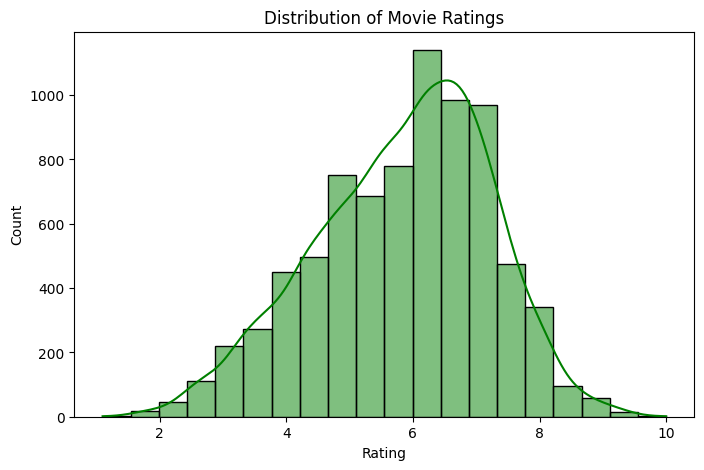

In [33]:
plt.figure(figsize=(8, 5))
sea.histplot(data['Rating'], bins=20, kde=True, color='green')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

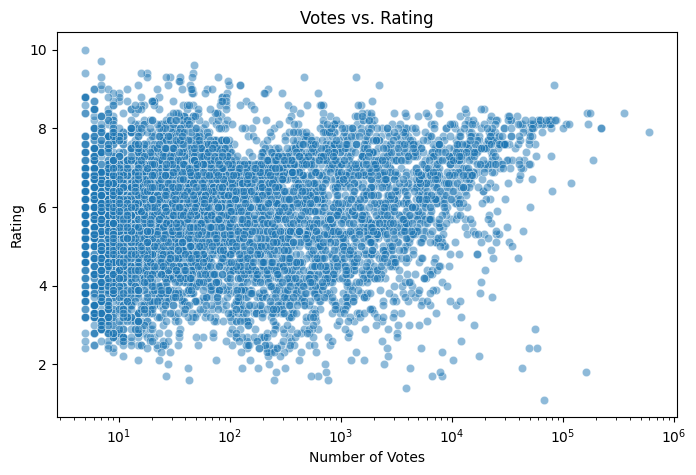

In [34]:
plt.figure(figsize=(8, 5))
sea.scatterplot(x='Votes', y='Rating', data=data, alpha=0.5)
plt.title('Votes vs. Rating')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.xscale('log')  # Use log scale to handle outliers
plt.show()


C:\Users\ankit\AppData\Local\Temp\ipykernel_15712\3998285803.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(x=top_directors.index, y=top_directors.values, palette='magma')


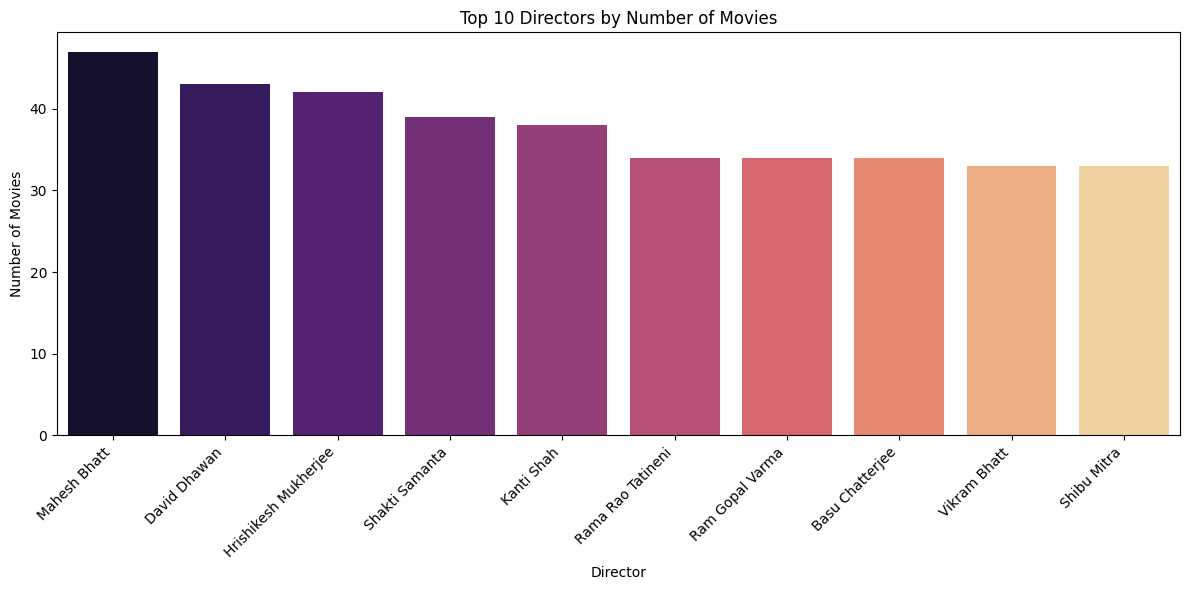

In [37]:
# Get top 10 directors by number of movies
top_directors = data['Director'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))
sea.barplot(x=top_directors.index, y=top_directors.values, palette='magma')

# Beautify
plt.xticks(rotation=45, ha='right')  # Rotate director names for readability
plt.title('Top 10 Directors by Number of Movies')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()


C:\Users\ankit\AppData\Local\Temp\ipykernel_15712\3459462989.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(x=top_actors.index, y=top_actors.values, palette='plasma')


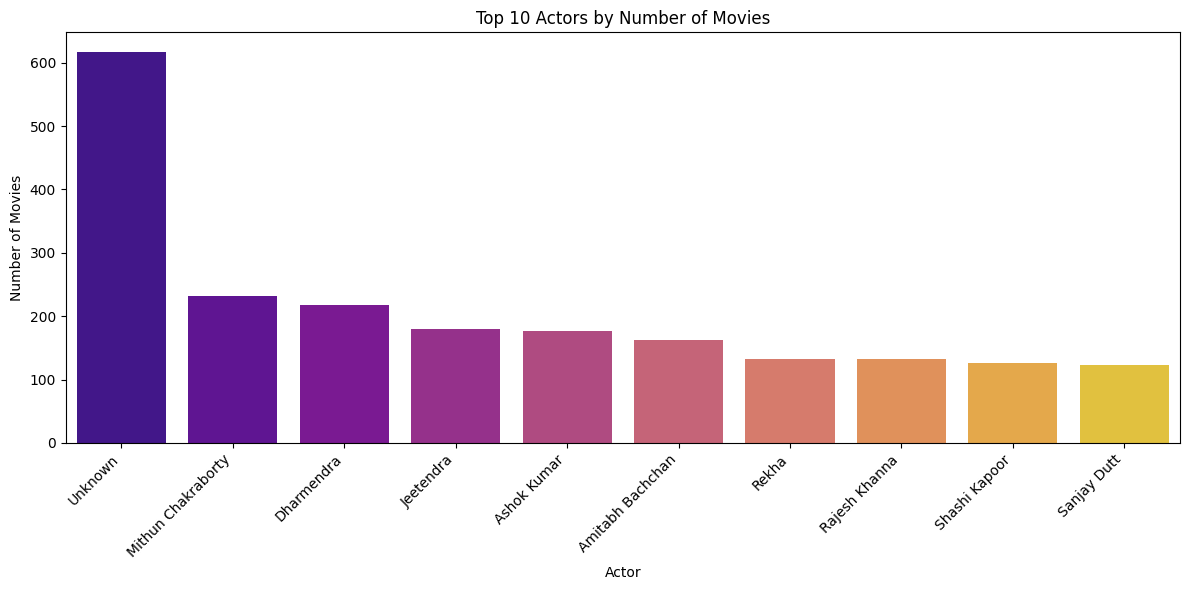

In [41]:
# Combine all actor columns into a single Series
all_actors = pd.concat([data['Actor 1'], data['Actor 2'], data['Actor 3']])

# Count appearances of each actor
top_actors = all_actors.value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))
sea.barplot(x=top_actors.index, y=top_actors.values, palette='plasma')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Actors by Number of Movies')
plt.xlabel('Actor')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

In [43]:

data.info(

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      0 non-null      float64
 1   Rating    7919 non-null   float64
 2   Votes     7919 non-null   float64
 3   Director  7919 non-null   object 
 4   Actor 1   7919 non-null   object 
 5   Actor 2   7919 non-null   object 
 6   Actor 3   7919 non-null   object 
 7   ['nan']   7919 non-null   int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 495.1+ KB


In [45]:

object_columns = ['Director', 'Actor 1', 'Actor 2', 'Actor 3']
# For each column, calculate the frequency of each name and map it back
for col in object_columns:
    # Count how many times each name appears
    freq_map = data[col].value_counts()
    
    # Map those counts to a new column
    data[col + '_freq'] = data[col].map(freq_map)

# Now drop the original string columns (optional, to keep things clean)
# data.drop(columns=object_columns, inplace=True)
print(data[['Director_freq', 'Actor 1_freq', 'Actor 2_freq', 'Actor 3_freq']].head())

   Director_freq  Actor 1_freq  Actor 2_freq  Actor 3_freq
0              1             2             1             1
1              1             5             1             2
2             17            18            15            13
3              7            25             4             8
4              1             1             6             1


In [58]:
data_model = data.drop(columns=['Director', 'Actor 1', 'Actor 2', 'Actor 3'])

**Step 3 Model Building**

In [59]:
# importing modules
from sklearn.model_selection import train_test_split

X = data_model.drop('Rating', axis=1)  # All columns except 'Rating'
y = data_model['Rating']               # The column we want to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Year']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Year']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
y_pred = model.predict(X_test)  # Predict ratings for the test data

In [63]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 1.7904422052715065
R² Score: 0.03695404617376219


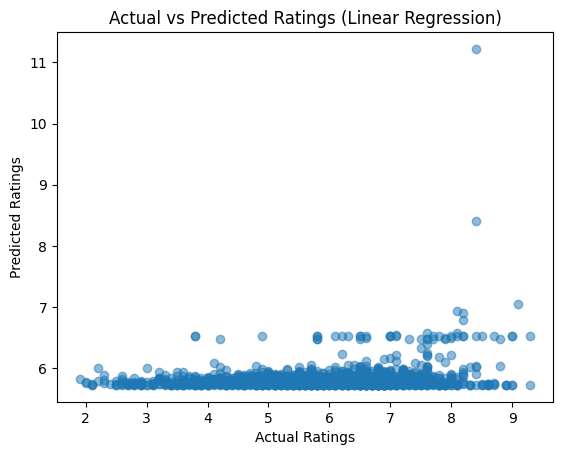

In [64]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (Linear Regression)")
plt.show()

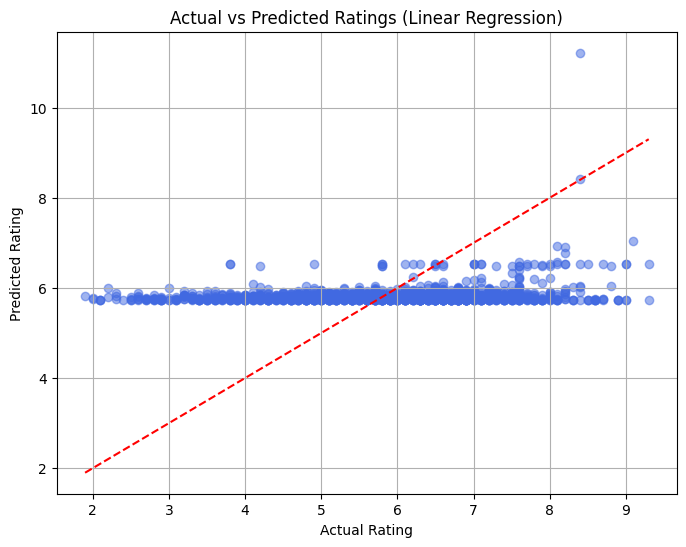

In [65]:
# Scatter plot of Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Diagonal line
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (Linear Regression)")
plt.grid(True)
plt.show()

In [66]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predictions already made as y_pred
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Mean Squared Error (MSE):", round(mse, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 3))

Mean Absolute Error (MAE): 1.088
Mean Squared Error (MSE): 1.79
Root Mean Squared Error (RMSE): 1.338
R² Score: 0.037


In [67]:
from sklearn.ensemble import RandomForestRegressor

# Train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

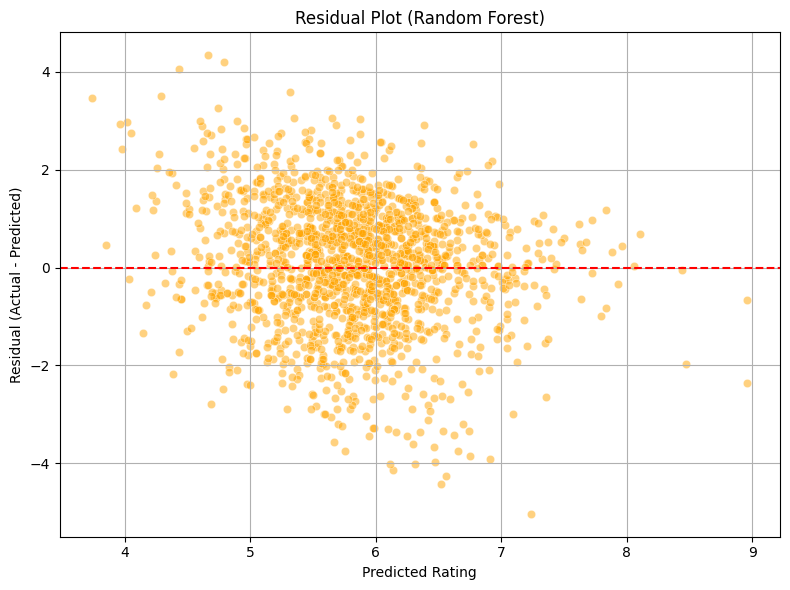

In [69]:
# Calculate residuals
residuals = y_test - rf_pred

# Plot residuals
plt.figure(figsize=(8, 6))
sea.scatterplot(x=rf_pred, y=residuals, alpha=0.5, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rating")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Random Forest)")
plt.grid(True)
plt.tight_layout()
plt.show()